# Load factor control

In [1]:
#
# Hockling problem, as desribed by Perez and Filippou (2024).
#
# https://onlinelibrary.wiley.com/doi/10.1002/nme.7506
#
from xara.benchmarks import Prism
import xara
from shps.rotor import exp
import numpy as np
import veux
import matplotlib.pyplot as plt


ne = 20
E  = 71_240
G  = 27_190
I  = 0.0833
A  = 10.0
J  = 2.16
L  = 240.0

def create_model(element):
    prism = Prism(
        length = L,
        element = element,
        material = dict(
            E   = E,
            G   = G,
        ),
        shape   = dict(
            A   = A,
            J   = J,
            Iy  = I,
            Iz  = I,
            Ay  = A,
            Az  = A),
        boundary = ((1,1,1, 1,1,1),
                    (0,1,1, 0,1,1)),
        transform = "Corotational02" if "Force" in element else "Spherical",
        divisions = ne,
        rotation = exp([0,  0.0, 0.005])
    )

    return prism.create_model()

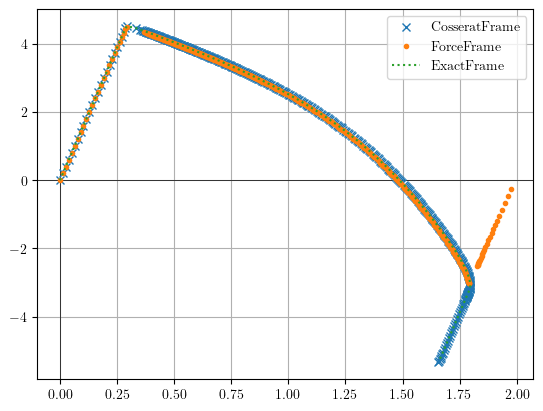

In [2]:


fig, ax = plt.subplots()
ax.grid("on")
ax.axvline(0, color='k', lw=0.5)
ax.axhline(0, color='k', lw=0.5)

Markers = iter(("x", ".", ":"))
for element in ["CosseratFrame", "ForceFrame", "ExactFrame"]:
    model = create_model(element)

    #
    # Analysis
    #
    scale = 5 #0.0
    steps = 65
    Tref  = 2*E*I/L

    f = [0, 0, 0] + list(map(float, [Tref, 0, 0]))
    model.pattern("Plain", 1, "Linear", load={
        ne+1: f
    })

    analysis = xara.StaticAnalysis(model, 
                                   test=("NormDispIncr", 1e-9, 52, 0),
                                #    test=("Energy", 1e-15, 52, 0),
                                   integrator=("MinUnbalDispNorm", 1/5, 5,  1/steps/200, 1/5),
                                   system="BandGeneral")

    u = []
    lam = []
    time = []

    for i in range(450):
        u.append(model.nodeDisp(ne+1, 4)/np.pi)
        time.append(model.getTime())
        lam.append(model.getLoadFactor(1))
        try:
            analysis.analyze()
        except:
            break

#       artist.draw_outlines(state=model.nodeDisp)

    ax.plot(u, time, next(Markers), label=element)



ax.legend()


In [3]:
from xara.shapes import Equigon

# shape = WideFlange(d=L/25, b=L/30, t=L/200)
shape = Equigon(radius=L/50, divisions=8)

artist = veux.create_artist(model, vertical=3)

artist.draw_sections(position=model.nodeDisp, 
                     rotation=model.nodeRotation,
                     outline="long",
                     shape=shape)
artist

In [4]:
artist.save("hockling.glb")

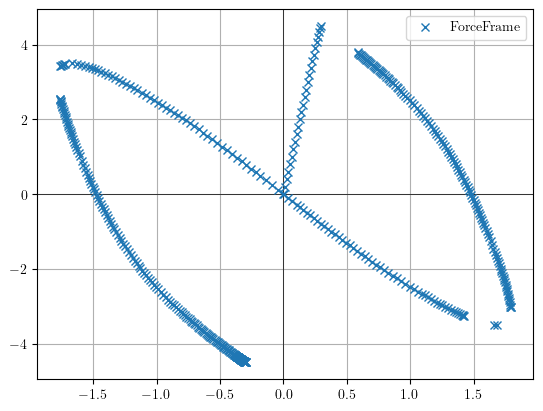

In [5]:
# Test energy instead of norm of displacement
fig, ax = plt.subplots()
ax.grid("on")
ax.axvline(0, color='k', lw=0.5)
ax.axhline(0, color='k', lw=0.5)


shape = Equigon(radius=L/50, divisions=8)
artist = veux.create_artist(model, vertical=3, model_config={
    "extrude_outline": shape
})
from veux.motion import Motion 
motion = Motion(artist)


Markers = iter(("x", ".", ":"))

element  = "ForceFrame" #"CosseratFrame", , "ExactFrame"
model = create_model(element)

#
# Analysis
#
scale = 5 #0.0
steps = 65
Tref  = 2*E*I/L

f = [0, 0, 0] + list(map(float, [Tref, 0, 0]))
model.pattern("Plain", 1, "Linear", load={
    ne+1: f
})

analysis = xara.StaticAnalysis(model, 
                                test=("Energy", 1e-15, 52, 0),
                                integrator=("MinUnbalDispNorm", 1/5, 5,  1/steps/200, 1/5),
                                system="BandGeneral")

u = []
lam = []
time = []

for i in range(450):
    u.append(model.nodeDisp(ne+1, 4)/np.pi)
    time.append(model.getTime())
    lam.append(model.getLoadFactor(1))
    try:
        analysis.analyze()
    except:
        break
    motion.draw_sections(rotation=model.nodeRotation, 
                         position=model.nodeDisp)
    motion.advance(time=15*i/450)


ax.plot(u, time, next(Markers), label=element)

ax.legend()

motion.add_to(artist.canvas)
artist